# From Behavioral Phenomena to Latent Dynamics

Freely moving behavior looks continuous and high-dimensional, yet recurring
sub-second motifs suggest that a smaller latent process may organize it. We use
mouse depth-video principal components as observations and ask:

> Can a latent-state model discover reusable behavioral states and their dynamics?

The path is deliberately narrow:

1. observed behavior and low-dimensional trajectories;
2. a discrete latent-state hypothesis;
3. HMM inference with forward–backward and EM;
4. Gaussian HMMs for state-dependent posture;
5. AR-HMMs for state-dependent short-timescale dynamics;
6. the conceptual step from AR-HMMs to continuous-state LDS models.

![Behavioral motifs](https://ars.els-cdn.com/content/image/1-s2.0-S0896627315010375-gr1.jpg)

**References:** Wiltschko et al. (2015), *Neuron*; Markowitz et al.
(2018), *Cell*.


## 1. From observations to a modeling question

The raw video is high-dimensional. Precomputed principal components retain the
dominant posture variation and give a multivariate trajectory $x_t$. The colored
background in the first visualization is an external MoSeq labeling used only
as orientation—not as supervision for fitting our models.


In [2]:
# Verify packages in the active Jupyter kernel without modifying the environment.
from importlib.util import find_spec
import sys

required_packages = {
    "pynwb": "pynwb",
    "dynamax": "dynamax>=1.0.1",
    "jaxtyping": "jaxtyping",
    "cv2": "opencv-python",
}
missing_packages = [
    pip_name
    for module_name, pip_name in required_packages.items()
    if find_spec(module_name) is None
]

if missing_packages:
    install_list = " ".join(f'"{package}"' for package in missing_packages)
    raise ModuleNotFoundError(
        "Missing notebook dependencies. Run this command in a new cell:\n"
        f"%pip install {install_list}"
    )

print(f"Environment ready: {sys.executable}")


Environment ready: c:\Users\10993\.conda\envs\Deeplearning\python.exe


In [3]:
# First, import necessary libraries.
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import trange
from pynwb import NWBHDF5IO

from pathlib import Path
import shutil
import urllib.request
import zipfile

from typing import List, Dict, Tuple, Optional, Any, Union, Sequence
from jaxtyping import Float, Int, UInt8

import torch
from torch.distributions import MultivariateNormal, Normal

# Specify that we want our tensors on the GPU and in float32
device = torch.device('cpu')
dtype = torch.float32

Number = Union[int, float]

# Helper function to convert between numpy arrays and tensors
to_t = lambda array: torch.tensor(array, device=device, dtype=dtype)
from_t = lambda tensor: tensor.to("cpu").detach().numpy().astype(np.float64)


In [4]:
sns.set_context('notebook')
palette = sns.xkcd_palette(['windows blue', 'red', 'medium green', 'dusty purple', 'greyish', 'orange', 'amber', 'clay', 'pink'])

def plot_data_and_states(data: Dict[str, Union[torch.Tensor, np.ndarray, Any]], states: Union[torch.Tensor, np.ndarray], spc: int=4, slc: slice=slice(0, 900), title: Optional[str]=None) -> None:
    times = data['times'][slc]
    labels = data['labels'][slc]
    x = data['data'][slc]
    num_timesteps, data_dim = x.shape
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.imshow(states[None, slc], cmap='cubehelix', aspect='auto', extent=(0, times[-1] - times[0], -data_dim * spc, spc))
    ax.plot(times - times[0], x - spc * np.arange(data_dim), ls='-', lw=3, color='w')
    ax.plot(times - times[0], x - spc * np.arange(data_dim), ls='-', lw=2, color=palette[0])
    ax.set_yticks(-spc * np.arange(data_dim))
    ax.set_yticklabels(np.arange(data_dim))
    ax.set_ylabel('principal component')
    ax.set_xlim(0, times[-1] - times[0])
    ax.set_xlabel('time [ms]')
    if title is None:
        ax.set_title('data and discrete states')
    else:
        ax.set_title(title)

def extract_syllable_slices(state_idx: Int[torch.Tensor, ''], posteriors: List[Dict[str, Float[torch.Tensor, 'num_timesteps num_states']]], pad: int=30, num_instances: int=50, min_duration: int=5, max_duration: int=45, seed: int=0) -> List[List[slice]]:
    state_idx = from_t(state_idx)
    all_mouse_inds = []
    all_starts = []
    all_durations = []
    for mouse, posterior in enumerate(posteriors):
        expected_states = from_t(posterior['expected_states'])
        states = np.argmax(expected_states, axis=1)
        states = np.concatenate([[-1], states, [-1]])
        starts = np.where((states[1:] == state_idx) & (states[:-1] != state_idx))[0]
        stops = np.where((states[:-1] == state_idx) & (states[1:] != state_idx))[0]
        durations = stops - starts
        assert np.all(durations >= 1)
        all_mouse_inds.append(mouse * np.ones(len(starts), dtype=int))
        all_starts.append(starts)
        all_durations.append(durations)
    all_mouse_inds = np.concatenate(all_mouse_inds)
    all_starts = np.concatenate(all_starts)
    all_durations = np.concatenate(all_durations)
    valid = (all_durations >= min_duration) & (all_durations < max_duration) & (all_starts > pad)
    num_valid = np.sum(valid)
    all_mouse_inds = all_mouse_inds[valid]
    all_starts = all_starts[valid]
    all_durations = all_durations[valid]
    rng = npr.RandomState(seed)
    subset = rng.choice(num_valid, size=min(num_valid, num_instances), replace=False)
    all_mouse_inds = all_mouse_inds[subset]
    all_starts = all_starts[subset]
    all_durations = all_durations[subset]
    slices = []
    for mouse in range(len(posteriors)):
        is_mouse = all_mouse_inds == mouse
        slices.append([slice(start, start + dur) for start, dur in zip(all_starts[is_mouse], all_durations[is_mouse])])
    return slices

def plot_average_pcs(state_idx: Union[int, Int[torch.Tensor, '']], dataset: List[Dict[str, Union[Float[torch.Tensor, 'Any num_features'], Float[np.ndarray, 'Any num_features']]]], posteriors: List[Dict[str, Float[torch.Tensor, 'num_timesteps num_states']]], spc: int=4, pad: int=30) -> None:
    slices = extract_syllable_slices(state_idx, posteriors, num_instances=1000)
    data_dim = dataset[0]['data'].shape[1]
    durs = []
    num_slices = 0
    for these_slices in slices:
        for slc in these_slices:
            durs.append(slc.stop - slc.start)
            num_slices += 1
    if num_slices == 0:
        print('no valid syllables found for state', state_idx)
        return
    max_dur = np.max(durs)
    times = np.arange(-pad, max_dur + pad) / fps
    exs = np.nan * np.ones((num_slices, 2 * pad + max_dur, data_dim))
    counter = 0
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    for these_slices, data, posterior in zip(slices, dataset, posteriors):
        for slc in these_slices:
            lpad = min(pad, slc.start)
            rpad = min(pad, len(data['data']) - slc.stop)
            dur = slc.stop - slc.start
            padded_slc = slice(slc.start - lpad, slc.stop + rpad)
            x = data['data'][padded_slc]
            exs[counter][pad - lpad:pad - lpad + len(x)] = x
            counter += 1
    ex_mean = np.nanmean(exs, axis=0)
    ex_std = np.nanstd(exs, axis=0)
    for d in range(data_dim):
        ax.fill_between(times, ex_mean[:, d] - 2 * ex_std[:, d] - spc * d, ex_mean[:, d] + 2 * ex_std[:, d] - spc * d, color='k', alpha=0.25)
        ax.plot(times, ex_mean[:, d] - spc * d, '-k', lw=2)
    ax.plot([0, 0], [-spc * data_dim, spc], '-r', lw=2)
    ax.set_yticks(-spc * np.arange(data_dim))
    ax.set_yticklabels(np.arange(data_dim))
    ax.set_ylim(-spc * data_dim, spc)
    ax.set_ylabel('principal component')
    ax.set_xlim(times[0], times[-1])
    ax.set_xlabel('$\\Delta t$ [ms]')
    ax.set_title('Average PCs for State {}'.format(state_idx))


### Load the MoSeq/NWB application data

The setup cell downloads the public archive only when it is absent. The main
analysis loads eight sessions and ten principal components; video frames are
disabled because they are not needed for the modeling argument.


In [5]:
# Download and extract the official MoSeq NWB archive when it is not cached.
DATA_URL = (
    "https://github.com/slinderman/ml4nd/raw/refs/heads/main/"
    "data/06_arhmm/moseq_data.zip"
)

cwd = Path.cwd().resolve()
project_notebook_dir = cwd / "VAE-Tutorial" / "Part2_Dynamics"
NOTEBOOK_DIR = project_notebook_dir if project_notebook_dir.exists() else cwd
DATA_DIR = NOTEBOOK_DIR / "data" / "moseq"
ARCHIVE_PATH = DATA_DIR / "moseq_data.zip"
DATA_DIR.mkdir(parents=True, exist_ok=True)

nwb_files = sorted(DATA_DIR.rglob("saline_example_*.nwb"))
if not nwb_files:
    if not ARCHIVE_PATH.exists():
        print(f"Downloading the 578 MB course archive to {ARCHIVE_PATH} ...")
        urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
    print(f"Extracting {ARCHIVE_PATH} ...")
    with zipfile.ZipFile(ARCHIVE_PATH, "r") as archive:
        archive.extractall(DATA_DIR)
    nwb_files = sorted(DATA_DIR.rglob("saline_example_*.nwb"))

if not nwb_files:
    raise FileNotFoundError(f"No saline_example_*.nwb files found under {DATA_DIR}")

NWB_FILES_BY_INDEX = {
    int(path.stem.rsplit("_", 1)[-1]): path
    for path in nwb_files
}
print(f"Found {len(NWB_FILES_BY_INDEX)} NWB files in {DATA_DIR}")


Found 24 NWB files in D:\Variational-Neural-Inference\VAE-Tutorial\Part2_Dynamics\data\moseq


In [6]:
def load_dataset(indices: Optional[Union[np.ndarray, Sequence[int]]]=None, load_frames: bool=False, num_pcs: int=10) -> Tuple[List[Dict[str, Union[Float[torch.Tensor, 'num_train_frames num_pcs_loaded'], Float[torch.Tensor, 'num_train_frames']]]], List[Dict[str, Union[Float[torch.Tensor, 'num_test_frames num_pcs_loaded'], Float[torch.Tensor, 'num_test_frames'], UInt8[torch.Tensor, 'num_test_frames frame_height frame_width']]]]]:
    if indices is None:
        indices = np.arange(24)
    train_dataset = []
    test_dataset = []
    for t in trange(len(indices)):
        i = indices[t]
        if int(i) not in NWB_FILES_BY_INDEX:
            raise FileNotFoundError(f'Missing NWB session index {i} in {DATA_DIR}')
        nwb_path = NWB_FILES_BY_INDEX[int(i)]
        with NWBHDF5IO(str(nwb_path), mode='r', load_namespaces=False) as io:
            f = io.read()
            num_frames = len(f.processing['MoSeq']['PCs']['pcs_clean'].data)
            train_slc = slice(0, int(0.8 * num_frames))
            test_slc = slice(int(0.8 * num_frames) + 1, -1)
            train_data, test_data = (dict(), dict())
            for slc, data in zip([train_slc, test_slc], [train_data, test_data]):
                data['raw_pcs'] = to_t(f.processing['MoSeq']['PCs']['pcs_clean'].data[slc][:, :num_pcs])
                data['times'] = to_t(f.processing['MoSeq']['PCs']['pcs_clean'].timestamps[slc][:])
                data['centroid_x_px'] = to_t(f.processing['MoSeq']['Scalars']['centroid_x_px'].data[slc][:])
                data['centroid_y_px'] = to_t(f.processing['MoSeq']['Scalars']['centroid_y_px'].data[slc][:])
                data['angles'] = to_t(f.processing['MoSeq']['Scalars']['angle'].data[slc][:])
                data['labels'] = to_t(f.processing['MoSeq']['Labels']['labels_clean'].data[slc][:])
            if load_frames:
                test_data['frames'] = torch.tensor(f.processing['MoSeq']['Images']['frames'].data[test_slc])
        train_dataset.append(train_data)
        test_dataset.append(test_data)
    return (train_dataset, test_dataset)
fps = 30
data_dim = 10
indices = np.arange(8)
train_dataset, test_dataset = load_dataset(num_pcs=data_dim, indices=indices, load_frames=False)


  0%|          | 0/8 [00:00<?, ?it/s]

In [7]:
def standardize_pcs(dataset: List[Dict[str, Any]], mean: Optional[Float[torch.Tensor, 'num_pcs']]=None, std: Optional[Float[torch.Tensor, 'num_pcs']]=None) -> Tuple[List[Dict[str, Any]], Float[torch.Tensor, 'num_pcs'], Float[torch.Tensor, 'num_pcs']]:
    if mean is None and std is None:
        all_pcs = torch.vstack([data['raw_pcs'] for data in dataset])
        mean = all_pcs.mean(axis=0)
        std = all_pcs.std(axis=0)
    for data in dataset:
        data['data'] = (data['raw_pcs'] - mean) / std
    return (dataset, mean, std)
train_dataset, mean, std = standardize_pcs(train_dataset)
test_dataset, _, _ = standardize_pcs(test_dataset, mean, std)


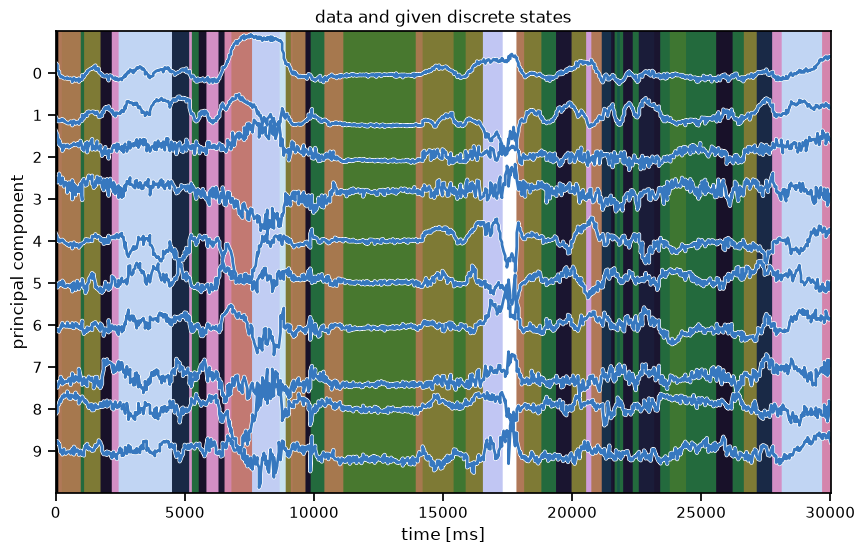

In [8]:
plot_data_and_states(train_dataset[0], train_dataset[0]["labels"],
                     title="data and given discrete states")

## 2. The discrete latent-state hypothesis

An HMM assumes that an unobserved discrete state $z_t$ evolves according to a
Markov transition matrix and generates the observation $x_t$:

$$p(z_{1:T},x_{1:T})=p(z_1)\prod_{t=2}^T p(z_t\mid z_{t-1})
\prod_{t=1}^T p(x_t\mid z_t).$$

The scientific interpretation is concrete: each state represents a recurring
behavioral regime, while transitions describe how behavior switches over time.


### Posterior inference: forward–backward

Forward messages combine past evidence with the current observation; backward
messages carry future evidence. Their product yields the smoothed state
posterior $p(z_t\mid x_{1:T})$. The implementation is retained below as
supporting code, but the inference principle—not the bookkeeping—is the main
point.


In [9]:
def sticky_transitions(num_states: int, stickiness: float=0.95) -> Float[torch.Tensor, 'num_states num_states']:
    P = stickiness * torch.eye(num_states)
    P += (1 - stickiness) / (num_states - 1) * (1 - torch.eye(num_states))
    return P

def random_args(num_timesteps: int, num_states: int, seed: int=0, offset: Number=0, scale: Number=1) -> Tuple[Float[torch.Tensor, 'num_states'], Float[torch.Tensor, 'num_states num_states'], Float[torch.Tensor, 'num_timesteps num_states']]:
    torch.manual_seed(seed)
    pi = torch.ones(num_states) / num_states
    P = sticky_transitions(num_states)
    log_likes = offset + scale * Normal(0, 1).sample((num_timesteps, num_states))
    return (pi, P, log_likes)


In [10]:
def forward_pass(initial_dist: Float[torch.Tensor, 'num_states'], transition_matrix: Float[torch.Tensor, 'num_states num_states'], log_likes: Float[torch.Tensor, 'num_timesteps num_states']) -> Tuple[Float[torch.Tensor, 'num_timesteps num_states'], Float[torch.Tensor, '']]:
    T, K = log_likes.shape
    device = log_likes.device
    dtype = log_likes.dtype
    alphas = torch.zeros((T, K), device=device, dtype=dtype)
    log_marginal_ll = 0.0
    log_lik_t = log_likes[0]
    log_lik_max = torch.max(log_lik_t)
    lik_t = torch.exp(log_lik_t - log_lik_max)
    alpha_t = initial_dist * lik_t
    alpha_t_sum = alpha_t.sum()
    alphas[0] = alpha_t / alpha_t_sum
    log_marginal_ll = torch.log(alpha_t_sum) + log_lik_max
    for t in range(1, T):
        log_lik_t = log_likes[t]
        log_lik_max = torch.max(log_lik_t)
        lik_t = torch.exp(log_lik_t - log_lik_max)
        pred = transition_matrix.T @ alphas[t - 1]
        alpha_t = lik_t * pred
        alpha_t_sum = alpha_t.sum()
        alphas[t] = alpha_t / alpha_t_sum
        log_marginal_ll = log_marginal_ll + torch.log(alpha_t_sum) + log_lik_max
    return (alphas, log_marginal_ll)


In [11]:
def backward_pass(transition_matrix: Float[torch.Tensor, 'num_states num_states'], log_likes: Float[torch.Tensor, 'num_timesteps num_states']) -> Float[torch.Tensor, 'num_timesteps num_states']:
    T, K = log_likes.shape
    device = log_likes.device
    dtype = log_likes.dtype
    betas = torch.zeros((T, K), device=device, dtype=dtype)
    betas[-1] = torch.ones(K, device=device, dtype=dtype) / K
    for t in range(T - 2, -1, -1):
        log_lik_next = log_likes[t + 1]
        log_lik_max = torch.max(log_lik_next)
        lik_next = torch.exp(log_lik_next - log_lik_max)
        weighted_beta = lik_next * betas[t + 1]
        beta_t = transition_matrix @ weighted_beta
        beta_t_sum = beta_t.sum()
        betas[t] = beta_t / beta_t_sum
    return betas


In [12]:
def E_step(initial_dist: Float[torch.Tensor, 'num_states'], transition_matrix: Float[torch.Tensor, 'num_states num_states'], log_likes: Float[torch.Tensor, 'num_timesteps num_states']) -> Dict[str, Union[Float[torch.Tensor, 'num_timesteps num_states'], Float[torch.Tensor, '']]]:
    T, K = log_likes.shape
    device = log_likes.device
    dtype = log_likes.dtype
    alphas, marginal_ll = forward_pass(initial_dist, transition_matrix, log_likes)
    betas = backward_pass(transition_matrix, log_likes)
    log_alphas = torch.log(alphas + 1e-10)
    log_betas = torch.log(betas + 1e-10)
    log_posteriors = log_alphas + log_likes + log_betas
    log_posteriors_max = torch.max(log_posteriors, dim=1, keepdim=True)[0]
    posteriors_unnorm = torch.exp(log_posteriors - log_posteriors_max)
    posteriors_sum = posteriors_unnorm.sum(dim=1, keepdim=True)
    expected_states = posteriors_unnorm / posteriors_sum
    posterior = dict(expected_states=expected_states, marginal_ll=marginal_ll)
    return posterior


In [13]:
def initialize_posteriors(dataset: List[Dict[str, Any]], num_states: int, seed: int=0) -> List[Dict[str, Union[Float[torch.Tensor, 'num_timesteps num_states'], float]]]:
    torch.manual_seed(seed)
    posteriors = []
    for data in dataset:
        expected_states = torch.rand(len(data['data']), num_states)
        expected_states /= expected_states.sum(axis=1, keepdims=True)
        posteriors.append(dict(expected_states=expected_states, marginal_ll=-torch.inf))
    return posteriors


## 3. Gaussian HMM: state-dependent posture

The Gaussian HMM gives every discrete state its own mean posture and covariance:

$$p(x_t\mid z_t=k)=\mathcal N(x_t\mid \mu_k,\Sigma_k).$$

EM alternates between inferring state probabilities (E-step) and updating the
state-specific observation parameters (M-step).


In [14]:
class GaussianObservations(object):
    num_states: int
    data_dim: int
    means: Float[torch.Tensor, 'num_states data_dim']
    covs: Float[torch.Tensor, 'num_states data_dim data_dim']

    def __init__(self, num_states: int, data_dim: int) -> None:
        self.num_states = num_states
        self.data_dim = data_dim
        self.means = torch.zeros((num_states, data_dim))
        self.covs = torch.tile(torch.eye(data_dim), (num_states, 1, 1))

    @staticmethod
    def precompute_suff_stats(dataset: List[Dict[str, Any]]) -> None:
        for data in dataset:
            x = data['data']
            data['suff_stats'] = (torch.ones(len(x)), x, torch.einsum('ti,tj->tij', x, x))

    def log_likelihoods(self, data: Dict[str, Any]) -> Float[torch.Tensor, 'num_timesteps num_states']:
        x = data['data']
        T = x.shape[0]
        log_likes = torch.zeros((T, self.num_states))
        for k in range(self.num_states):
            try:
                dist = MultivariateNormal(self.means[k], self.covs[k])
                log_likes[:, k] = dist.log_prob(x)
            except:
                log_likes[:, k] = -10000000000.0
        return log_likes

    def M_step(self, stats: Tuple[Float[torch.Tensor, 'num_states'], Float[torch.Tensor, 'num_states data_dim'], Float[torch.Tensor, 'num_states data_dim data_dim']]) -> None:
        Ns, t1s, t2s = stats
        self.means = t1s / (Ns.unsqueeze(1) + 1e-10)
        for k in range(self.num_states):
            if Ns[k] > 0:
                cov = t2s[k] / (Ns[k] + 1e-10) - torch.outer(self.means[k], self.means[k])
                cov = cov + 0.0001 * torch.eye(self.data_dim)
                self.covs[k] = cov
            else:
                self.covs[k] = torch.eye(self.data_dim)


In [15]:
GaussianObservations.precompute_suff_stats(train_dataset)
GaussianObservations.precompute_suff_stats(test_dataset)


In [16]:
def compute_expected_suff_stats(dataset: List[Dict[str, Any]], posteriors: List[Dict[str, Any]]) -> Tuple[torch.Tensor, ...]:
    assert isinstance(dataset, list)
    assert isinstance(posteriors, list)

    def _compute_expected_suff_stats(data, posterior):
        q = posterior['expected_states']
        suff_stats = data['suff_stats']
        expected_stats = []
        for stat in suff_stats:
            if stat.dim() == 1:
                exp_stat = (q.T @ stat.unsqueeze(1)).squeeze(1)
            elif stat.dim() == 2:
                exp_stat = q.T @ stat
            elif stat.dim() == 3:
                exp_stat = torch.einsum('tk,tij->kij', q, stat)
            else:
                raise ValueError(f'Unexpected dimension: {stat.dim()}')
            expected_stats.append(exp_stat)
        return (len(data['data']), tuple(expected_stats))
    combined_T = 0
    combined_stats = None
    for data, posterior in zip(dataset, posteriors):
        this_T, these_stats = _compute_expected_suff_stats(data, posterior)
        combined_T += this_T
        if combined_stats is None:
            combined_stats = these_stats
        else:
            combined_stats = tuple((cs + ts for cs, ts in zip(combined_stats, these_stats)))
    if combined_T > 0:
        combined_stats = tuple((s / combined_T for s in combined_stats))
    return combined_stats


In [17]:
def fit_hmm(train_dataset: List[Dict[str, Any]], test_dataset: List[Dict[str, Any]], initial_dist: Float[torch.Tensor, 'num_states'], transition_matrix: Float[torch.Tensor, 'num_states num_states'], observations: Any, seed: int=0, num_iters: int=50) -> Tuple[Float[torch.Tensor, 'num_iters'], Float[torch.Tensor, 'num_iters'], List[Dict[str, Union[Float[torch.Tensor, 'num_timesteps num_states'], Float[torch.Tensor, '']]]], List[Dict[str, Union[Float[torch.Tensor, 'num_timesteps num_states'], Float[torch.Tensor, '']]]]]:
    num_states = observations.num_states
    num_train = sum([len(data['data']) for data in train_dataset])
    num_test = sum([len(data['data']) for data in test_dataset])
    assert initial_dist.shape == (num_states,) and torch.all(initial_dist >= 0) and torch.isclose(initial_dist.sum(), torch.tensor(1.0))
    assert transition_matrix.shape == (num_states, num_states) and torch.all(transition_matrix >= 0) and torch.allclose(transition_matrix.sum(axis=1), torch.tensor(1.0))
    posteriors = initialize_posteriors(train_dataset, num_states, seed=seed)
    stats = compute_expected_suff_stats(train_dataset, posteriors)
    train_lls = []
    test_lls = []
    for itr in trange(num_iters):
        observations.M_step(stats)
        posteriors = []
        for data in train_dataset:
            log_likes = observations.log_likelihoods(data)
            posterior = E_step(initial_dist, transition_matrix, log_likes)
            posteriors.append(posterior)
        stats = compute_expected_suff_stats(train_dataset, posteriors)
        avg_train_ll = sum([p['marginal_ll'] for p in posteriors]) / num_train
        train_lls.append(torch.tensor(avg_train_ll) if not isinstance(avg_train_ll, torch.Tensor) else avg_train_ll)
        test_posteriors = []
        for data in test_dataset:
            log_likes = observations.log_likelihoods(data)
            posterior = E_step(initial_dist, transition_matrix, log_likes)
            test_posteriors.append(posterior)
        avg_test_ll = sum([p['marginal_ll'] for p in test_posteriors]) / num_test
        test_lls.append(torch.tensor(avg_test_ll) if not isinstance(avg_test_ll, torch.Tensor) else avg_test_ll)
    train_lls = torch.stack(train_lls)
    test_lls = torch.stack(test_lls)
    return (train_lls, test_lls, posteriors, test_posteriors)


  0%|          | 0/15 [00:00<?, ?it/s]

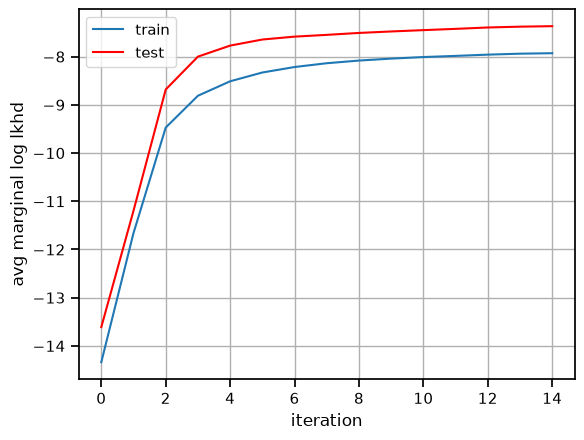

In [18]:
# Build the HMM
num_states = 20
initial_dist = torch.ones(num_states) / num_states
transition_matrix = sticky_transitions(num_states, stickiness=0.95)
observations = GaussianObservations(num_states, data_dim)

# Fit the HMM with EM
train_lls, test_lls, train_posteriors, test_posteriors, = \
    fit_hmm(train_dataset[:1],
            test_dataset[:1],
            initial_dist,
            transition_matrix,
            observations,
            num_iters=15)

plt.plot(train_lls, label="train")
plt.plot(test_lls, '-r', label="test")
plt.xlabel("iteration")
plt.ylabel("avg marginal log lkhd")
plt.grid(True)
plt.legend()

### What did the Gaussian HMM discover?


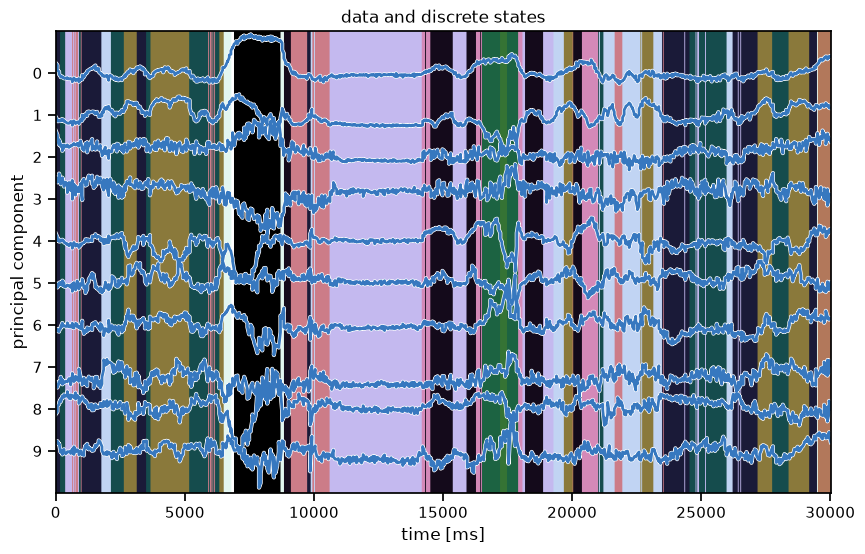

In [19]:
ghmm_states = train_posteriors[0]["expected_states"].argmax(1)
plot_data_and_states(train_dataset[0], ghmm_states)

Text(0.5, 1.0, 'histogram of inferred state usage')

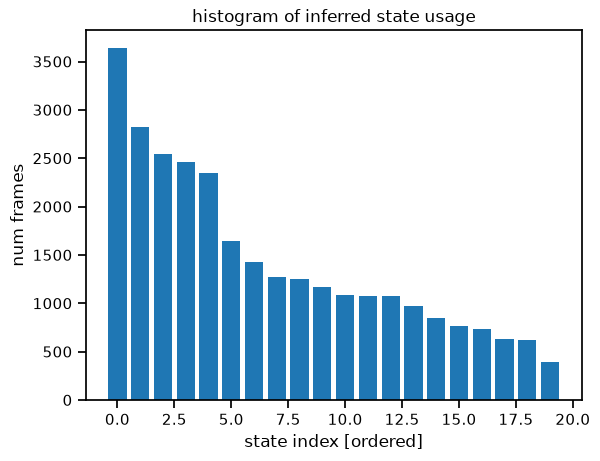

In [20]:
# Sort states by usage
ghmm_usage = torch.bincount(ghmm_states, minlength=num_states)
ghmm_order = torch.argsort(ghmm_usage, descending=True)

plt.bar(torch.arange(num_states), ghmm_usage[ghmm_order])
plt.xlabel("state index [ordered]")
plt.ylabel("num frames")
plt.title("histogram of inferred state usage")

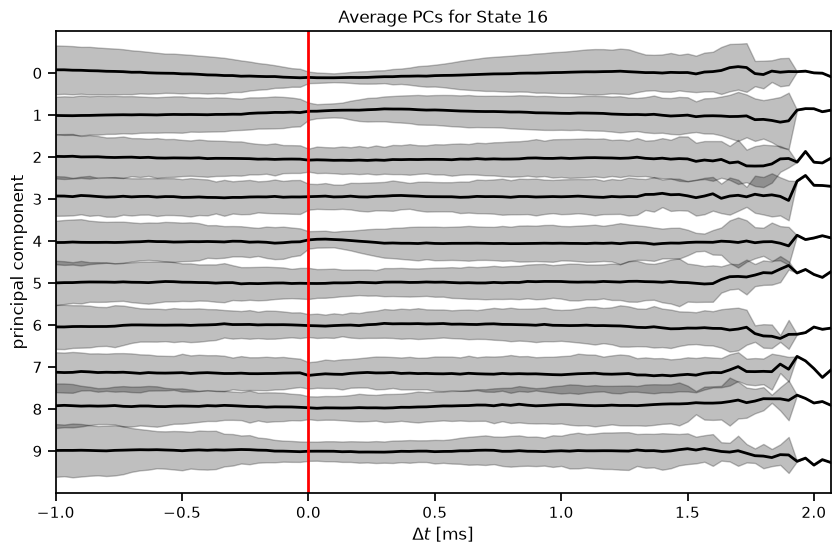

In [21]:
plot_average_pcs(ghmm_order[3], train_dataset, train_posteriors)

### Limitation

A Gaussian HMM clusters instantaneous posture. It can identify recurring
regions of observation space, but it does not explicitly describe how posture
evolves *within* a state. That limitation motivates an autoregressive emission
model.


## 4. AR-HMM: state-dependent local dynamics

An AR-HMM lets each state define a local dynamical rule:

$$p(x_t\mid x_{t-1:t-G},z_t=k)
=\mathcal N\!\left(\sum_{g=1}^{G}A_{k,g}x_{t-g}+b_k,Q_k\right).$$

The latent state now selects not just a posture distribution, but a short-term
movement pattern.


In [22]:
class LinearRegressionObservations(object):
    num_states: int
    data_dim: int
    covariate_dim: int
    weights: Float[torch.Tensor, 'num_states data_dim covariate_dim']
    covs: Float[torch.Tensor, 'num_states data_dim data_dim']

    def __init__(self, num_states: int, data_dim: int, covariate_dim: int) -> None:
        self.num_states = num_states
        self.data_dim = data_dim
        self.covariate_dim = covariate_dim
        self.weights = torch.zeros((num_states, data_dim, covariate_dim))
        self.covs = torch.tile(torch.eye(data_dim), (num_states, 1, 1))

    @staticmethod
    def precompute_suff_stats(dataset: List[Dict[str, Any]]) -> None:
        for data in dataset:
            x = data['data']
            x_cov = data.get('covariates', None)
            if x_cov is None:
                raise ValueError("Covariates must be provided in data['covariates']")
            T = x.shape[0]
            data['suff_stats'] = (torch.ones(T), torch.einsum('ti,tj->tij', x, x_cov), torch.einsum('ti,tj->tij', x, x), torch.einsum('ti,tj->tij', x_cov, x_cov))

    def log_likelihoods(self, data: Dict[str, Any]) -> Float[torch.Tensor, 'num_timesteps num_states']:
        x = data['data']
        x_cov = data.get('covariates', None)
        if x_cov is None:
            raise ValueError('Covariates must be provided')
        T = x.shape[0]
        log_likes = torch.zeros((T, self.num_states))
        for k in range(self.num_states):
            mu = (self.weights[k] @ x_cov.T).T
            try:
                dist = MultivariateNormal(mu, self.covs[k])
                log_likes[:, k] = dist.log_prob(x)
            except:
                log_likes[:, k] = -10000000000.0
        return log_likes

    def M_step(self, stats: Tuple[Float[torch.Tensor, 'num_states'], Float[torch.Tensor, 'num_states data_dim covariate_dim'], Float[torch.Tensor, 'num_states data_dim data_dim'], Float[torch.Tensor, 'num_states covariate_dim covariate_dim']]) -> None:
        Ns, XYTs, YYTs, XXTs = stats
        for k in range(self.num_states):
            if Ns[k] > 1e-10:
                try:
                    XXTs_reg = XXTs[k] + 1e-06 * torch.eye(self.covariate_dim)
                    self.weights[k] = XYTs[k] @ torch.linalg.inv(XXTs_reg)
                    cov = (YYTs[k] - self.weights[k] @ XYTs[k].T - XYTs[k] @ self.weights[k].T + self.weights[k] @ XXTs[k] @ self.weights[k].T) / Ns[k]
                    cov = cov + 0.0001 * torch.eye(self.data_dim)
                    self.covs[k] = cov
                except:
                    self.covs[k] = torch.eye(self.data_dim)
            else:
                self.covs[k] = torch.eye(self.data_dim)


In [23]:
def precompute_ar_covariates(dataset: List[Dict[str, Any]], num_lags: int=2, fit_intercept: bool=True) -> None:
    for data in dataset:
        x = data['data']
        T = x.shape[0]
        data_dim = x.shape[1]
        covariates_list = []
        for lag in range(1, num_lags + 1):
            lagged = torch.cat([torch.zeros((lag, data_dim)), x[:-lag]], dim=0)
            covariates_list.append(lagged)
        covariates = torch.cat(covariates_list, dim=1)
        if fit_intercept:
            intercept = torch.ones((T, 1))
            covariates = torch.cat([covariates, intercept], dim=1)
        data['covariates'] = covariates


In [24]:
num_lags = 2
precompute_ar_covariates(train_dataset, num_lags=2)
precompute_ar_covariates(test_dataset, num_lags=2)
LinearRegressionObservations.precompute_suff_stats(train_dataset)
LinearRegressionObservations.precompute_suff_stats(test_dataset)


  0%|          | 0/15 [00:00<?, ?it/s]

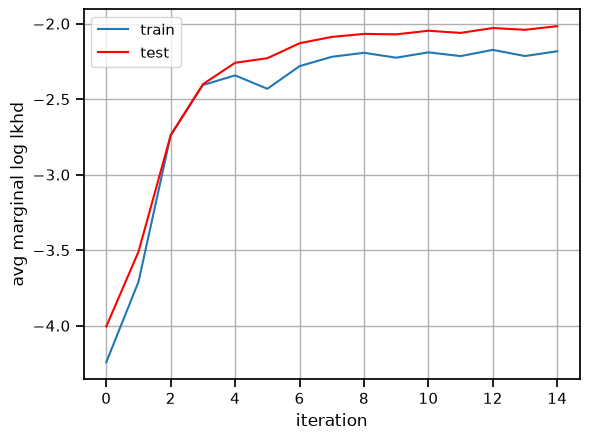

In [25]:
# Build the HMM
num_states = 20
initial_dist = torch.ones(num_states) / num_states
transition_matrix = sticky_transitions(num_states, stickiness=0.95)
observations = LinearRegressionObservations(num_states, data_dim,
                                            num_lags * data_dim + 1)

# Fit it!
train_lls, test_lls, train_posteriors, test_posteriors, = \
    fit_hmm(train_dataset[:1],
            test_dataset[:1],
            initial_dist,
            transition_matrix,
            observations,
            num_iters=15)

plt.plot(train_lls, label="train")
plt.plot(test_lls, '-r', label="test")
plt.xlabel("iteration")
plt.ylabel("avg marginal log lkhd")
plt.grid(True)
plt.legend()

### What did the AR-HMM discover?


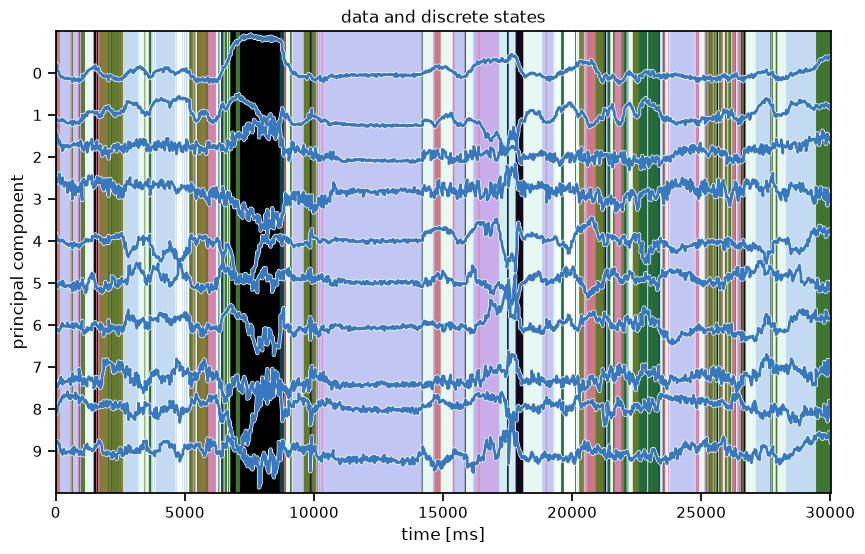

In [26]:
arhmm_states = train_posteriors[0]["expected_states"].argmax(1)
plot_data_and_states(train_dataset[0], arhmm_states)

Text(0.5, 1.0, 'histogram of inferred state usage')

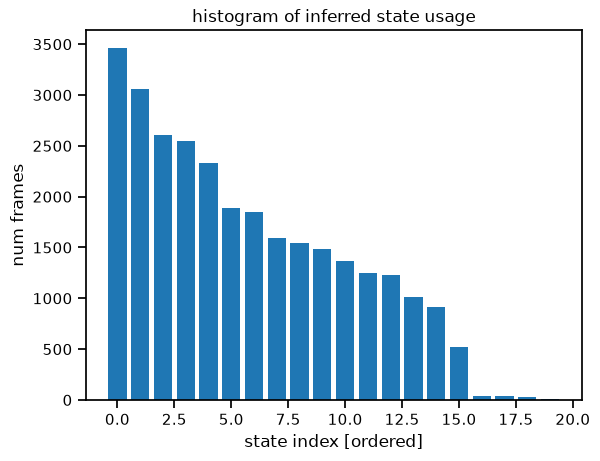

In [27]:
# Sort states by usage
arhmm_states = train_posteriors[0]["expected_states"].argmax(1)
arhmm_usage = torch.bincount(arhmm_states, minlength=num_states)
arhmm_order = torch.argsort(arhmm_usage, descending=True)

plt.bar(torch.arange(num_states), arhmm_usage[arhmm_order])
plt.xlabel("state index [ordered]")
plt.ylabel("num frames")
plt.title("histogram of inferred state usage")

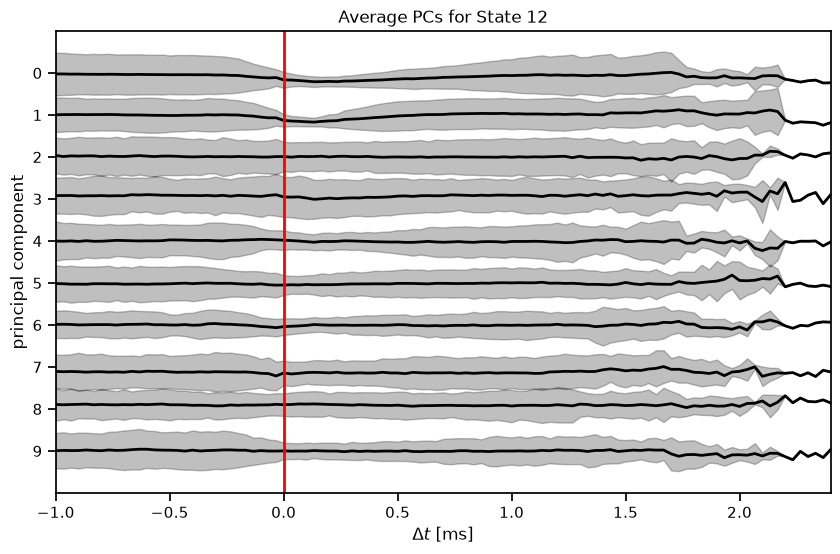

In [28]:
plot_average_pcs(arhmm_order[3], train_dataset[:1], train_posteriors[:1])


## 5. From AR-HMMs to LDS models

The AR-HMM still makes the *observed* trajectory autoregressive and keeps the
latent state discrete. A linear dynamical system introduces a continuous latent
trajectory $h_t$ instead:

$$h_t=A h_{t-1}+\epsilon_t,\qquad y_t=C h_t+\eta_t.$$

This distinction matters:

| Model | Latent state | What evolves dynamically? |
|---|---|---|
| Gaussian HMM | discrete $z_t$ | state sequence |
| AR-HMM | discrete $z_t$ | observed trajectory within each state |
| LDS | continuous $h_t$ | latent trajectory |
| Switching/GP-LDS | discrete + continuous | regime-specific latent dynamics |

Thus the main progression is **behavioral motifs → discrete latent states →
local dynamics → continuous latent dynamics**. The GP-SLDS notebook continues
from this point.


## Take-home message

- High-dimensional behavior can be summarized by a lower-dimensional trajectory.
- HMMs turn recurring structure into interpretable discrete latent states.
- Gaussian emissions describe state-dependent posture.
- Autoregressive emissions add state-dependent local dynamics.
- LDS-family models move the dynamics into a continuous latent space, providing
  the bridge to modern neural latent-dynamics models.
